# Customer Segmentation using K-Means Clustering
## E-commerce Customer Analysis

## Task 1 — Data Preprocessing
### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load Dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [5]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Step 3: Clean Data
- Drop CustomerID
- Encode Gender

In [7]:
df = df.drop('CustomerID', axis=1)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [8]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


### Step 4: Outlier Detection

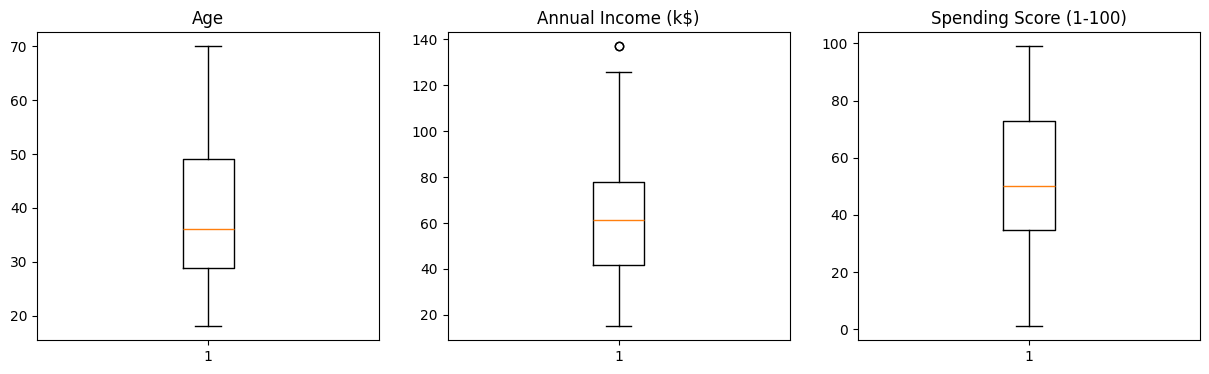

In [9]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.boxplot(df['Age'])
plt.title('Age')
plt.subplot(1,3,2)
plt.boxplot(df['Annual Income (k$)'])
plt.title('Annual Income (k$)')
plt.subplot(1,3,3)
plt.boxplot(df['Spending Score (1-100)'])
plt.title('Spending Score (1-100)')
plt.show()

### Step 5: Normalize Data

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled[:5])

[[-1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [-1.12815215 -1.28103541 -1.73899919  1.19570407]
 [ 0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [ 0.88640526 -1.13750203 -1.70082976  1.04041783]
 [ 0.88640526 -0.56336851 -1.66266033 -0.39597992]]


## Task 2 — Finding Optimal K
### Elbow Method

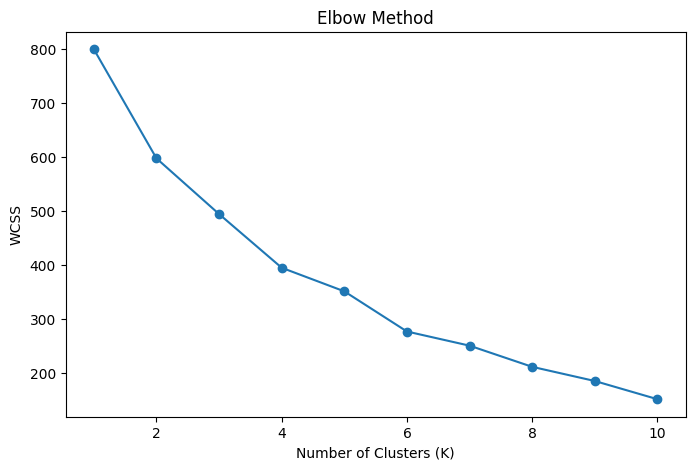

In [11]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

### Silhouette Score

In [12]:
from sklearn.metrics import silhouette_score

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={i} → Silhouette Score: {score:.3f}")

K=2 → Silhouette Score: 0.278
K=3 → Silhouette Score: 0.258
K=4 → Silhouette Score: 0.290
K=5 → Silhouette Score: 0.272
K=6 → Silhouette Score: 0.335
K=7 → Silhouette Score: 0.346
K=8 → Silhouette Score: 0.373
K=9 → Silhouette Score: 0.388
K=10 → Silhouette Score: 0.421


## Task 3 — Apply K-Means Clustering

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
df.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,2
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,4
4,1,31,17,40,4
5,1,22,17,76,4
6,1,35,18,6,4
7,1,23,18,94,4
8,0,64,19,3,0
9,1,30,19,72,4


## Task 4 — Cluster Visualization
### 2D Plot

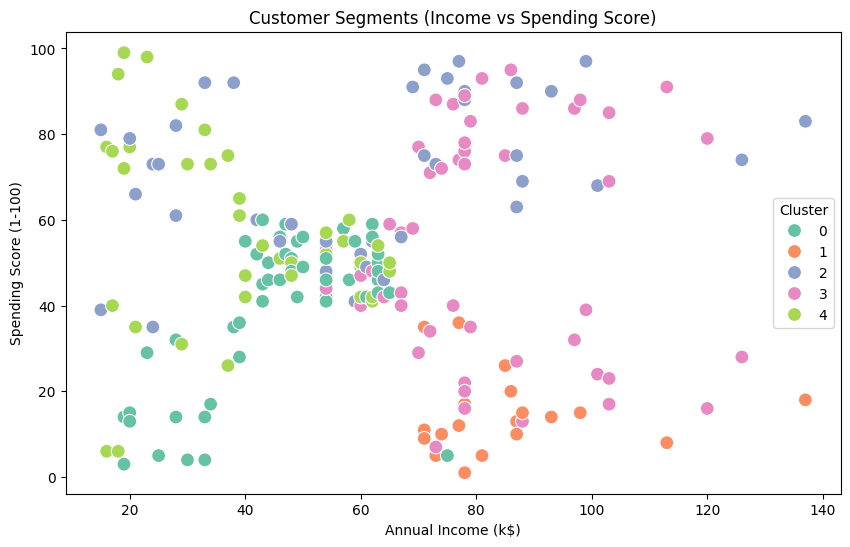

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set2',
    s=100
)

plt.title('Customer Segments (Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

### 3D Plot

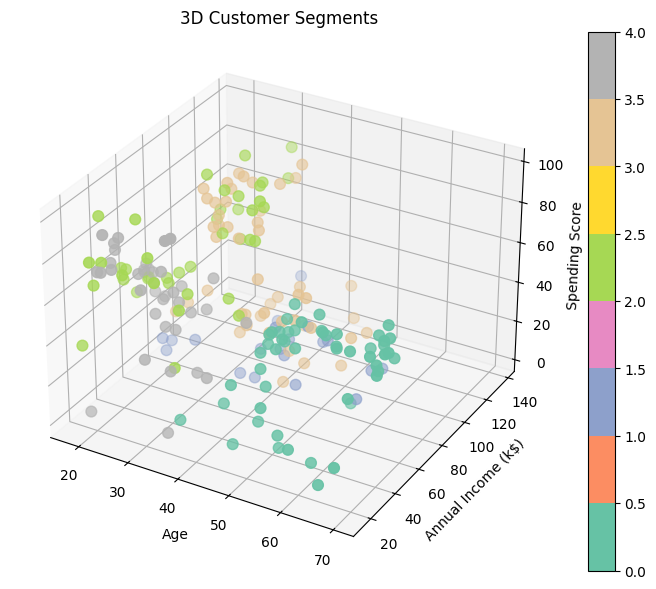

In [15]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='Set2',
    s=60
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title('3D Customer Segments')
plt.colorbar(scatter)
plt.show()

## Task 5 — Business Insights

In [16]:
cluster_summary = df.groupby('Cluster').mean().round(1)
print(cluster_summary)

         Gender   Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                          
0           0.5  56.5                46.1                    39.3
1           0.0  39.5                85.2                    14.0
2           0.0  28.7                60.9                    70.2
3           1.0  37.9                82.1                    54.4
4           1.0  27.3                38.8                    56.2


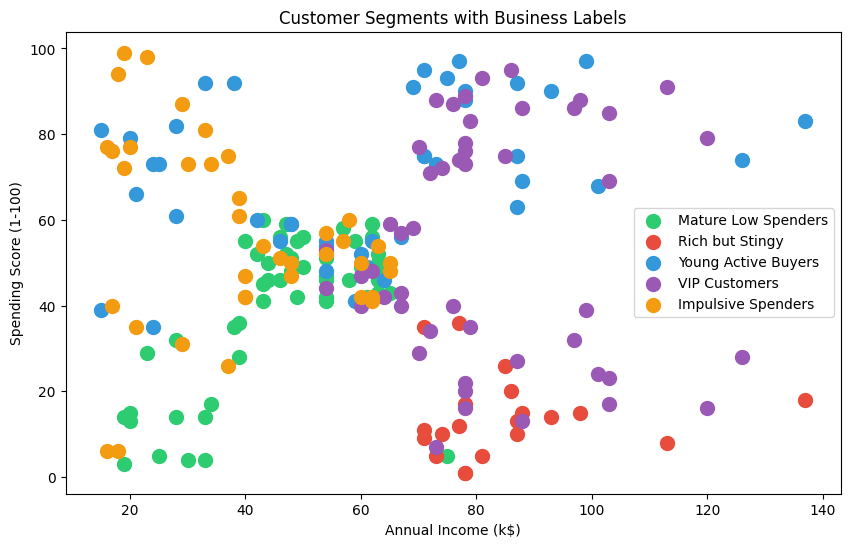

In [17]:
plt.figure(figsize=(10, 6))

colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']
labels = ['Mature Low Spenders', 'Rich but Stingy', 
          'Young Active Buyers', 'VIP Customers', 
          'Impulsive Spenders']

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        c=colors[i],
        label=labels[i],
        s=100
    )

plt.title('Customer Segments with Business Labels')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Task 6 — Predict New Customer

In [19]:
new_customer = pd.DataFrame([[0, 25, 40, 80]], 
                columns=['Gender', 'Age', 
                         'Annual Income (k$)', 
                         'Spending Score (1-100)'])

new_scaled = scaler.transform(new_customer)

cluster = kmeans.predict(new_scaled)

print(f"Customer belongs to Cluster {cluster[0]}: {cluster_names[cluster[0]]}")

Customer belongs to Cluster 2: Young Active Buyers 🛍️


In [20]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved!")

Model saved!
